<a href="https://colab.research.google.com/github/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/blob/main/QSAR_Part_2_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Assignment-3**

## **AI and Drug Discovery Course: QSAR Modeling**


# **Exploratory Data Analysis**

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')

## **Import Bioactivity Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving bioactivity_preprocessed_data.csv to bioactivity_preprocessed_data.csv


In [3]:
df4 = pd.read_csv("bioactivity_preprocessed_data.csv")
df4.head(10)


,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL185238,Cc1cccc(-c2n[nH]cc2-c2ccc3ncccc3n2)n1,16000.0,inactive
1,CHEMBL371694,CC(C)(C)c1nc(-c2ccc(F)cc2)c(-c2ccncc2)[nH]1,900.0,active
2,CHEMBL200259,OCc1cccc(-c2[nH]c(-c3ccccc3)nc2-c2ccncc2)c1,1585.0,intermediate
3,CHEMBL68215,Oc1ccc(-c2[nH]c(-c3ccccc3)nc2-c2ccncc2)cc1,339.0,active
4,CHEMBL200863,CC(C)(CNC(=O)Nc1ccc(Cl)cc1)c1nc(-c2ccc(Cl)c(O)...,13.0,active
5,CHEMBL381447,CC(C)(CNS(C)(=O)=O)c1nc(-c2ccc(Cl)c(O)c2)c(-c2...,14.0,active
6,CHEMBL426476,CN(C)CCCNC(=O)c1nc(-c2ccc(Cl)c(O)c2)c(-c2ccncc...,40.0,active
7,CHEMBL200889,CC(C)(CN)c1nc(-c2ccc(Cl)c(O)c2)c(-c2ccncc2)[nH]1,6.0,active
8,CHEMBL200320,NCc1ccc(-c2nc(-c3ccc(Cl)c(O)c3)c(-c3ccncc3)[nH...,8.0,active
9,CHEMBL200118,Oc1cc(-c2[nH]cnc2-c2ccncc2)ccc1Cl,33.0,active


## **Remove NA Values**

In [4]:
print("Original shape:", df4.shape)

df4 = df4.dropna(subset=[
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value"
])

# convert IC50 to numeric
df4["standard_value"] = pd.to_numeric(df4["standard_value"], errors="coerce")

df4 = df4.dropna(subset=["standard_value"])

df4 = df4[df4["bioactivity_class"] != 'intermediate']

print("After cleaning:", df4.shape)



Original shape: (10841, 4)
After cleaning: (10027, 4)


In [5]:
df4.head()

,molecule_chembl_id,canonical_smiles,standard_value,bioactivity_class
0,CHEMBL185238,Cc1cccc(-c2n[nH]cc2-c2ccc3ncccc3n2)n1,16000.0,inactive
1,CHEMBL371694,CC(C)(C)c1nc(-c2ccc(F)cc2)c(-c2ccncc2)[nH]1,900.0,active
3,CHEMBL68215,Oc1ccc(-c2[nH]c(-c3ccccc3)nc2-c2ccncc2)cc1,339.0,active
4,CHEMBL200863,CC(C)(CNC(=O)Nc1ccc(Cl)cc1)c1nc(-c2ccc(Cl)c(O)...,13.0,active
5,CHEMBL381447,CC(C)(CNS(C)(=O)=O)c1nc(-c2ccc(Cl)c(O)c2)c(-c2...,14.0,active


## **Aggregate Duplicates IC50 (median IC50 per canonical smile)**

In [6]:
df_clean = (
    df4
    .groupby("canonical_smiles", as_index=False)
    .agg({
        "molecule_chembl_id": "first",
        "standard_value": "median",
        "bioactivity_class": "first"
    })
)

print("Before aggregation:", df4.shape[0])
print("After aggregation:", df_clean.shape[0])

df_clean.head()


Before aggregation: 10027
After aggregation: 6131


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class
0,C#CC(C)(C)c1cc(N=C(C)C)cc(C(=O)Nc2ccc(C)c(C(=O...,CHEMBL475818,76.0,active
1,C#CC(C)(C)c1cccc(C(=O)Nc2ccc(C)c(Nc3ccc4ncn(C)...,CHEMBL4203441,24.5,active
2,C#CCCC(=O)Nc1nc2ccc(C(=O)c3ccccc3C(=O)Nc3ccc(F...,CHEMBL3974840,100.0,active
3,C#CCCC(=O)Nc1nc2ccc(C3(O)c4ccccc4C(=O)N3Cc3ccc...,CHEMBL3905522,100.0,active
4,C#CCOC(=O)Nc1nc2cc(C3(O)c4ccccc4C(=O)N3Cc3cccc...,CHEMBL3898105,100.0,active


In [7]:
df_clean.standard_value.describe()

,standard_value
count,6.131000e+03
mean,1.352696e+04
std,4.582495e+05
min,2.000000e-02
25%,4.000000e+00
50%,3.300000e+01
75%,1.878750e+02
max,2.500034e+07


## **Convert IC50 to pIC50**

Convert IC50 to the negative logarithmic scale which is essentially -log10(IC50). This conversion allows IC50 data to be more uniformly distributed.


In [8]:
df_clean["pIC50"] = -np.log10(df_clean["standard_value"] * 1e-9)

df_clean.head()


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,C#CC(C)(C)c1cc(N=C(C)C)cc(C(=O)Nc2ccc(C)c(C(=O...,CHEMBL475818,76.0,active,7.119186
1,C#CC(C)(C)c1cccc(C(=O)Nc2ccc(C)c(Nc3ccc4ncn(C)...,CHEMBL4203441,24.5,active,7.610834
2,C#CCCC(=O)Nc1nc2ccc(C(=O)c3ccccc3C(=O)Nc3ccc(F...,CHEMBL3974840,100.0,active,7.000000
3,C#CCCC(=O)Nc1nc2ccc(C3(O)c4ccccc4C(=O)N3Cc3ccc...,CHEMBL3905522,100.0,active,7.000000
4,C#CCOC(=O)Nc1nc2cc(C3(O)c4ccccc4C(=O)N3Cc3cccc...,CHEMBL3898105,100.0,active,7.000000


In [10]:
df_clean.pIC50.describe()

,pIC50
count,6131.000000
mean,7.371614
std,1.295035
min,1.602054
25%,6.726131
50%,7.481486
75%,8.397940
max,10.698970


## **Reassign Activity Labels Based on PIC50**

Based on pIC50  
Active >= 6  
Inactive < 6  

In [11]:
threshold = 6

df_clean["bioactivity_class"] = np.where(
    df_clean["pIC50"] >= threshold,
    "active",
    "inactive"
)

df_clean.head()


,canonical_smiles,molecule_chembl_id,standard_value,bioactivity_class,pIC50
0,C#CC(C)(C)c1cc(N=C(C)C)cc(C(=O)Nc2ccc(C)c(C(=O...,CHEMBL475818,76.0,active,7.119186
1,C#CC(C)(C)c1cccc(C(=O)Nc2ccc(C)c(Nc3ccc4ncn(C)...,CHEMBL4203441,24.5,active,7.610834
2,C#CCCC(=O)Nc1nc2ccc(C(=O)c3ccccc3C(=O)Nc3ccc(F...,CHEMBL3974840,100.0,active,7.000000
3,C#CCCC(=O)Nc1nc2ccc(C3(O)c4ccccc4C(=O)N3Cc3ccc...,CHEMBL3905522,100.0,active,7.000000
4,C#CCOC(=O)Nc1nc2cc(C3(O)c4ccccc4C(=O)N3Cc3cccc...,CHEMBL3898105,100.0,active,7.000000


## **Check Duplicates**

In [12]:
print("Duplicate SMILES remaining:",
      df_clean["canonical_smiles"].duplicated().sum())


Duplicate SMILES remaining: 0


In [13]:
df_clean.standard_value.describe()

,standard_value
count,6.131000e+03
mean,1.352696e+04
std,4.582495e+05
min,2.000000e-02
25%,4.000000e+00
50%,3.300000e+01
75%,1.878750e+02
max,2.500034e+07


In [14]:
df_clean.pIC50.describe()

,pIC50
count,6131.000000
mean,7.371614
std,1.295035
min,1.602054
25%,6.726131
50%,7.481486
75%,8.397940
max,10.698970


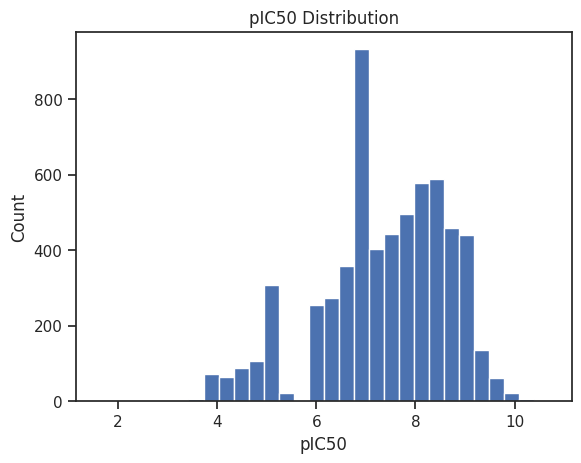

<Figure size 640x480 with 0 Axes>

In [15]:
plt.hist(df_clean["pIC50"], bins=30)
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("pIC50 Distribution")
plt.show()
plt.savefig('histogram_pic50.pdf')

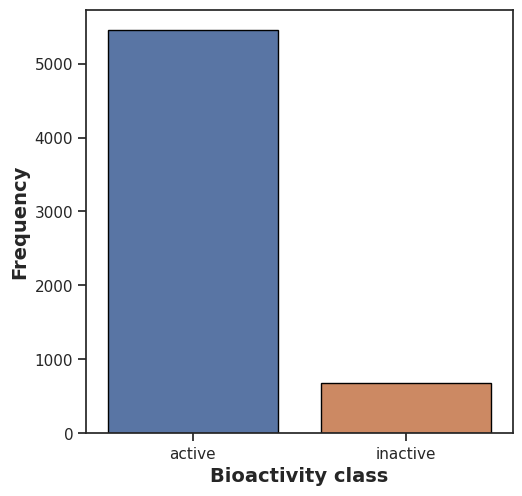

In [17]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="bioactivity_class", data= df_clean, hue="bioactivity_class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.savefig('count_plot.png')

# **Lipinski's Descriptor Calculation**

## **Install rdkit**

In [46]:
!pip install rdkit

In [47]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem import rdMolDescriptors

In [48]:
df_no_smiles = df_clean.drop(columns='canonical_smiles')

smiles = []

for i in df_clean.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key=len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name='canonical_smiles')

df_clean_smiles = pd.concat([df_no_smiles, smiles], axis=1)

df_clean_smiles


,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL475818,76.0,active,7.119186,C#CC(C)(C)c1cc(N=C(C)C)cc(C(=O)Nc2ccc(C)c(C(=O...
1,CHEMBL4203441,24.5,active,7.610834,C#CC(C)(C)c1cccc(C(=O)Nc2ccc(C)c(Nc3ccc4ncn(C)...
2,CHEMBL3974840,100.0,active,7.000000,C#CCCC(=O)Nc1nc2ccc(C(=O)c3ccccc3C(=O)Nc3ccc(F...
3,CHEMBL3905522,100.0,active,7.000000,C#CCCC(=O)Nc1nc2ccc(C3(O)c4ccccc4C(=O)N3Cc3ccc...
4,CHEMBL3898105,100.0,active,7.000000,C#CCOC(=O)Nc1nc2cc(C3(O)c4ccccc4C(=O)N3Cc3cccc...
...,...,...,...,...,...
6126,CHEMBL1780174,4.6,active,8.337242,c1ccc(-n2cc(-c3ccc4c(c3)Cc3c[nH]nc3-4)c(-c3ccn...
6127,CHEMBL4866102,1000.0,active,6.000000,c1ccc(COc2cccc(-c3nc4sccn4c3-c3ccncn3)c2)cc1
6128,CHEMBL1231605,100000.0,inactive,4.000000,c1ccc(Nc2c[nH]c3ncccc23)cc1
6129,CHEMBL1667902,4.0,active,8.397940,c1cnc(-c2oc3cnccc3c2Nc2ccc3c(c2)Cc2c[nH]nc2-3)nc1


## **Calculate descriptors**

In [49]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors



In [50]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,452.558,5.91772,2.0,4.0
1,450.542,5.14862,2.0,4.0
2,454.461,4.53720,3.0,4.0
3,450.498,3.76420,3.0,4.0
4,452.470,3.59400,3.0,5.0


In [51]:
df_lipinski.shape

(6131, 4)

Combine Both datasets

In [52]:
df_clean_smiles.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles
0,CHEMBL475818,76.0,active,7.119186,C#CC(C)(C)c1cc(N=C(C)C)cc(C(=O)Nc2ccc(C)c(C(=O...
1,CHEMBL4203441,24.5,active,7.610834,C#CC(C)(C)c1cccc(C(=O)Nc2ccc(C)c(Nc3ccc4ncn(C)...
2,CHEMBL3974840,100.0,active,7.000000,C#CCCC(=O)Nc1nc2ccc(C(=O)c3ccccc3C(=O)Nc3ccc(F...
3,CHEMBL3905522,100.0,active,7.000000,C#CCCC(=O)Nc1nc2ccc(C3(O)c4ccccc4C(=O)N3Cc3ccc...
4,CHEMBL3898105,100.0,active,7.000000,C#CCOC(=O)Nc1nc2cc(C3(O)c4ccccc4C(=O)N3Cc3cccc...


In [53]:
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,452.558,5.91772,2.0,4.0
1,450.542,5.14862,2.0,4.0
2,454.461,4.53720,3.0,4.0
3,450.498,3.76420,3.0,4.0
4,452.470,3.59400,3.0,5.0


In [54]:
df_combined = pd.concat([df_clean_smiles, df_lipinski], axis=1)
df_combined.head()

,molecule_chembl_id,standard_value,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL475818,76.0,active,7.119186,C#CC(C)(C)c1cc(N=C(C)C)cc(C(=O)Nc2ccc(C)c(C(=O...,452.558,5.91772,2.0,4.0
1,CHEMBL4203441,24.5,active,7.610834,C#CC(C)(C)c1cccc(C(=O)Nc2ccc(C)c(Nc3ccc4ncn(C)...,450.542,5.14862,2.0,4.0
2,CHEMBL3974840,100.0,active,7.000000,C#CCCC(=O)Nc1nc2ccc(C(=O)c3ccccc3C(=O)Nc3ccc(F...,454.461,4.53720,3.0,4.0
3,CHEMBL3905522,100.0,active,7.000000,C#CCCC(=O)Nc1nc2ccc(C3(O)c4ccccc4C(=O)N3Cc3ccc...,450.498,3.76420,3.0,4.0
4,CHEMBL3898105,100.0,active,7.000000,C#CCOC(=O)Nc1nc2cc(C3(O)c4ccccc4C(=O)N3Cc3cccc...,452.470,3.59400,3.0,5.0


In [55]:
df_combined = df_combined.drop(columns="standard_value")
df_combined.head()

,molecule_chembl_id,bioactivity_class,pIC50,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL475818,active,7.119186,C#CC(C)(C)c1cc(N=C(C)C)cc(C(=O)Nc2ccc(C)c(C(=O...,452.558,5.91772,2.0,4.0
1,CHEMBL4203441,active,7.610834,C#CC(C)(C)c1cccc(C(=O)Nc2ccc(C)c(Nc3ccc4ncn(C)...,450.542,5.14862,2.0,4.0
2,CHEMBL3974840,active,7.000000,C#CCCC(=O)Nc1nc2ccc(C(=O)c3ccccc3C(=O)Nc3ccc(F...,454.461,4.53720,3.0,4.0
3,CHEMBL3905522,active,7.000000,C#CCCC(=O)Nc1nc2ccc(C3(O)c4ccccc4C(=O)N3Cc3ccc...,450.498,3.76420,3.0,4.0
4,CHEMBL3898105,active,7.000000,C#CCOC(=O)Nc1nc2cc(C3(O)c4ccccc4C(=O)N3Cc3cccc...,452.470,3.59400,3.0,5.0


In [56]:
# Save CSV
df_combined.to_csv("df_lipinski.csv", index=False)